# Análisis Completo de Accidentes Fatality Histórico
Este notebook carga el CSV histórico de accidentes y realiza un análisis exploratorio similar al notebook de PCI Histórico.

## 1. Importar librerías necesarias

In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import warnings

warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 10

print('✓ Librerías cargadas correctamente')

✓ Librerías cargadas correctamente


## 2. Cargar los datos de Accidentes Fatality

In [16]:
file_path = r'../CSVS/accidentes-fatality-histo-cleaned.csv'
print('Cargando archivo CSV...')
df_acc = pd.read_csv(file_path)
print('✓ Archivo cargado exitosamente')
print(f'Forma del dataset: {df_acc.shape}')
print(f'Tamaño en memoria: {df_acc.memory_usage(deep=True).sum() / 1024 / 1024:.2f} MB')

Cargando archivo CSV...
✓ Archivo cargado exitosamente
Forma del dataset: (352, 13)
Tamaño en memoria: 0.21 MB


In [17]:
df_acc.head()

,unique_id,case_id_fkey,latitude,longitude,death_datetime,collision_datetime,location,age,sex,deceased,collision_type,street_type,analysis_neighborhood
0,1,140236301,37.710409,-122.404226,2014-03-20 11:21:00,2014-03-20 00:00:00,Bayshore Blvd near Visitation Ave,82.0,Female,Pedestrian,Pedestrian vs Motor Vehicle,City Street,Bayview Hunters Point
1,2,140755533,37.725476,-122.394243,2014-09-08 16:38:00,2014-09-08 05:10:00,3rd St at Carrol Ave,71.0,Male,Pedestrian,Pedestrian vs LRV,City Street,Bayview Hunters Point
2,3,151078623,37.726049,-122.406232,2015-12-14 10:30:00,2015-12-14 10:15:00,IFO 551 Goettingen St,63.0,Male,Bicyclist,Bicycle vs Motor Vehicle,City Street,Portola
3,4,140365546,37.748255,-122.413669,2014-05-03 17:20:00,2014-05-03 02:24:00,Folsom St and Caesar Chavez,26.0,Male,Driver,Motor Vehicle Collision,City Street,Mission
4,6,151090279,37.749170,-122.418148,2015-12-18 06:50:00,2015-12-18 02:20:00,Mission St at 26th St,28.0,Male,Pedestrian,Pedestrian vs Motor Vehicle,City Street,Mission


## 3. Información general del dataset

In [18]:
print('='*80)
print('INFORMACIÓN GENERAL DEL DATASET DE ACCIDENTES FATALITY')
print('='*80)
print(f'Número total de filas (registros): {df_acc.shape[0]:,}')
print(f'Número total de columnas: {df_acc.shape[1]}')
print(f'Tamaño en memoria: {df_acc.memory_usage(deep=True).sum() / 1024 / 1024:.2f} MB')
print('Memoria por columna:')
for col, mem in df_acc.memory_usage(deep=True).items():
    print(f'  {col:30s}: {mem / 1024 / 1024:6.2f} MB')

INFORMACIÓN GENERAL DEL DATASET DE ACCIDENTES FATALITY
Número total de filas (registros): 352
Número total de columnas: 13
Tamaño en memoria: 0.21 MB
Memoria por columna:
  Index                         :   0.00 MB
  unique_id                     :   0.00 MB
  case_id_fkey                  :   0.02 MB
  latitude                      :   0.00 MB
  longitude                     :   0.00 MB
  death_datetime                :   0.02 MB
  collision_datetime            :   0.02 MB
  location                      :   0.03 MB
  age                           :   0.00 MB
  sex                           :   0.02 MB
  deceased                      :   0.02 MB
  collision_type                :   0.02 MB
  street_type                   :   0.02 MB
  analysis_neighborhood         :   0.02 MB


## 4. Columnas y tipos de datos

In [19]:
print('' + '='*80)
print('COLUMNAS DEL DATASET DE ACCIDENTES')
print('='*80)
for i, col in enumerate(df_acc.columns, 1):
    print(f'{i:2d}. {col}')
print('' + '='*80)
print('TIPOS DE DATOS')
print('='*80)
print(df_acc.dtypes)

COLUMNAS DEL DATASET DE ACCIDENTES
 1. unique_id
 2. case_id_fkey
 3. latitude
 4. longitude
 5. death_datetime
 6. collision_datetime
 7. location
 8. age
 9. sex
10. deceased
11. collision_type
12. street_type
13. analysis_neighborhood
TIPOS DE DATOS
unique_id                  int64
case_id_fkey                 str
latitude                 float64
longitude                float64
death_datetime               str
collision_datetime           str
location                     str
age                      float64
sex                          str
deceased                     str
collision_type               str
street_type                  str
analysis_neighborhood        str
dtype: object


## 5. Análisis de valores nulos

In [20]:
null_analysis = pd.DataFrame({
    'Columna': df_acc.columns,
    'Valores Nulos': df_acc.isnull().sum().values,
    'Porcentaje (%)': (df_acc.isnull().sum().values / len(df_acc) * 100).round(2),
    'Valores Válidos': df_acc.notna().sum().values
})
print(null_analysis.to_string(index=False))
print(f'TOTAL de valores nulos en el dataset: {df_acc.isnull().sum().sum():,}')
print(f'Porcentaje total: {(df_acc.isnull().sum().sum() / (df_acc.shape[0] * df_acc.shape[1]) * 100):.2f}%')

              Columna  Valores Nulos  Porcentaje (%)  Valores Válidos
            unique_id              0             0.0              352
         case_id_fkey              0             0.0              352
             latitude              0             0.0              352
            longitude              0             0.0              352
       death_datetime              0             0.0              352
   collision_datetime              0             0.0              352
             location              0             0.0              352
                  age              0             0.0              352
                  sex              0             0.0              352
             deceased              0             0.0              352
       collision_type              0             0.0              352
          street_type              0             0.0              352
analysis_neighborhood              0             0.0              352
TOTAL de valores nul

## 5.1. Manejo de valores nulos
En este conjunto de datos, los nulos aparecen principalmente en `case_id_fkey`, `age` y `analysis_neighborhood`.
A continuación aplicamos estrategias de imputación y etiquetado para mantener la integridad del análisis.

In [21]:
null_cols = df_acc.columns[df_acc.isna().any()].tolist()
print('Columnas con valores nulos:', null_cols)
print(df_acc[null_cols].isna().sum())

# 1) case_id_fkey: clave foránea, mantener NaN pero marcarlo para análisis posterior
df_acc['case_id_fkey_missing'] = df_acc['case_id_fkey'].isna()

# 2) age: solo 1 valor faltante, es razonable imputar con la mediana
age_median = df_acc['age'].median()
df_acc['age_imputed'] = df_acc['age'].fillna(age_median)
df_acc['age_imputed_flag'] = df_acc['age'].isna()

# 3) analysis_neighborhood: categoría descriptiva, rellenar con 'Unknown'
if 'analysis_neighborhood' in df_acc.columns:
    df_acc['analysis_neighborhood'] = df_acc['analysis_neighborhood'].fillna('Unknown')

print('\nManejo aplicado:')
print(df_acc[['case_id_fkey_missing', 'age_imputed_flag', 'analysis_neighborhood']].head())


Columnas con valores nulos: []
Series([], dtype: float64)

Manejo aplicado:
   case_id_fkey_missing  age_imputed_flag  analysis_neighborhood
0                 False             False  Bayview Hunters Point
1                 False             False  Bayview Hunters Point
2                 False             False                Portola
3                 False             False                Mission
4                 False             False                Mission


## 6. Conversión de fechas y análisis temporal

In [22]:
df_acc['collision_datetime'] = pd.to_datetime(df_acc['collision_datetime'], errors='coerce')
df_acc['death_datetime'] = pd.to_datetime(df_acc['death_datetime'], errors='coerce')
df_acc['collision_year'] = df_acc['collision_datetime'].dt.year.astype('Int64')
df_acc['collision_month'] = df_acc['collision_datetime'].dt.month.astype('Int64')
print('Fechas convertidas correctamente')
print(f"Registros con fecha de colisión válida: {df_acc['collision_datetime'].notna().sum():,}")
print(f"Registros con fecha de colisión inválida: {df_acc['collision_datetime'].isna().sum():,}")

Fechas convertidas correctamente
Registros con fecha de colisión válida: 352
Registros con fecha de colisión inválida: 0


## 7. Distribución por año y por mes

In [23]:
if 'collision_year' not in df_acc.columns and 'collision_datetime' in df_acc.columns:
    df_acc['collision_year'] = df_acc['collision_datetime'].dt.year.astype('Int64')
if 'collision_month' not in df_acc.columns and 'collision_datetime' in df_acc.columns:
    df_acc['collision_month'] = df_acc['collision_datetime'].dt.month.astype('Int64')
yearly_counts = df_acc['collision_year'].value_counts().sort_index()
monthly_counts = df_acc['collision_month'].value_counts().sort_index()
print('Registros por año de colisión:')
print(yearly_counts)
print('Registros por mes de colisión:')
print(monthly_counts)


Registros por año de colisión:
collision_year
2014    30
2015    31
2016    29
2017    20
2018    23
2019    29
2020    26
2021    27
2022    38
2023    24
2024    42
2025    25
2026     8
Name: count, dtype: Int64
Registros por mes de colisión:
collision_month
1     24
2     26
3     42
4     17
5     34
6     30
7     25
8     33
9     29
10    32
11    27
12    33
Name: count, dtype: Int64


## 8. Análisis de variables categóricas

In [24]:
categorical_columns = [
    'sex', 'deceased', 'collision_type', 'street_type',
    'analysis_neighborhood', 'supervisor_district'
]
for col in categorical_columns:
    if col in df_acc.columns:
        counts = df_acc[col].value_counts(dropna=False)
        pct = (df_acc[col].value_counts(normalize=True, dropna=False) * 100).round(2)
        summary = pd.DataFrame({
            'Valor': counts.index.astype(str),
            'Cantidad': counts.values,
            'Porcentaje': pct.values
        })
        print('' + '='*60)
        print(f'Columna: {col}')
        print('='*60)
        print(summary.head(20).to_string(index=False))


Columna: sex
 Valor  Cantidad  Porcentaje
  Male       248       70.45
Female       104       29.55
Columna: deceased
                       Valor  Cantidad  Porcentaje
                  Pedestrian       208       59.09
                Motorcyclist        47       13.35
                      Driver        40       11.36
                   Bicyclist        25        7.10
                   Passenger        18        5.11
Standup Powered Device Rider         9        2.56
          Exterior Passenger         3        0.85
                       Moped         2        0.57
Columna: collision_type
                                 Valor  Cantidad  Porcentaje
           Pedestrian vs Motor Vehicle       190       53.98
               Motor Vehicle Collision        53       15.06
           Motorcycle vs Motor Vehicle        25        7.10
                  Motorcycle Collision        18        5.11
              Bicycle vs Motor Vehicle        17        4.83
        Motor Vehicle Collision (

## 9. Visualización de datos categóricos y temporales

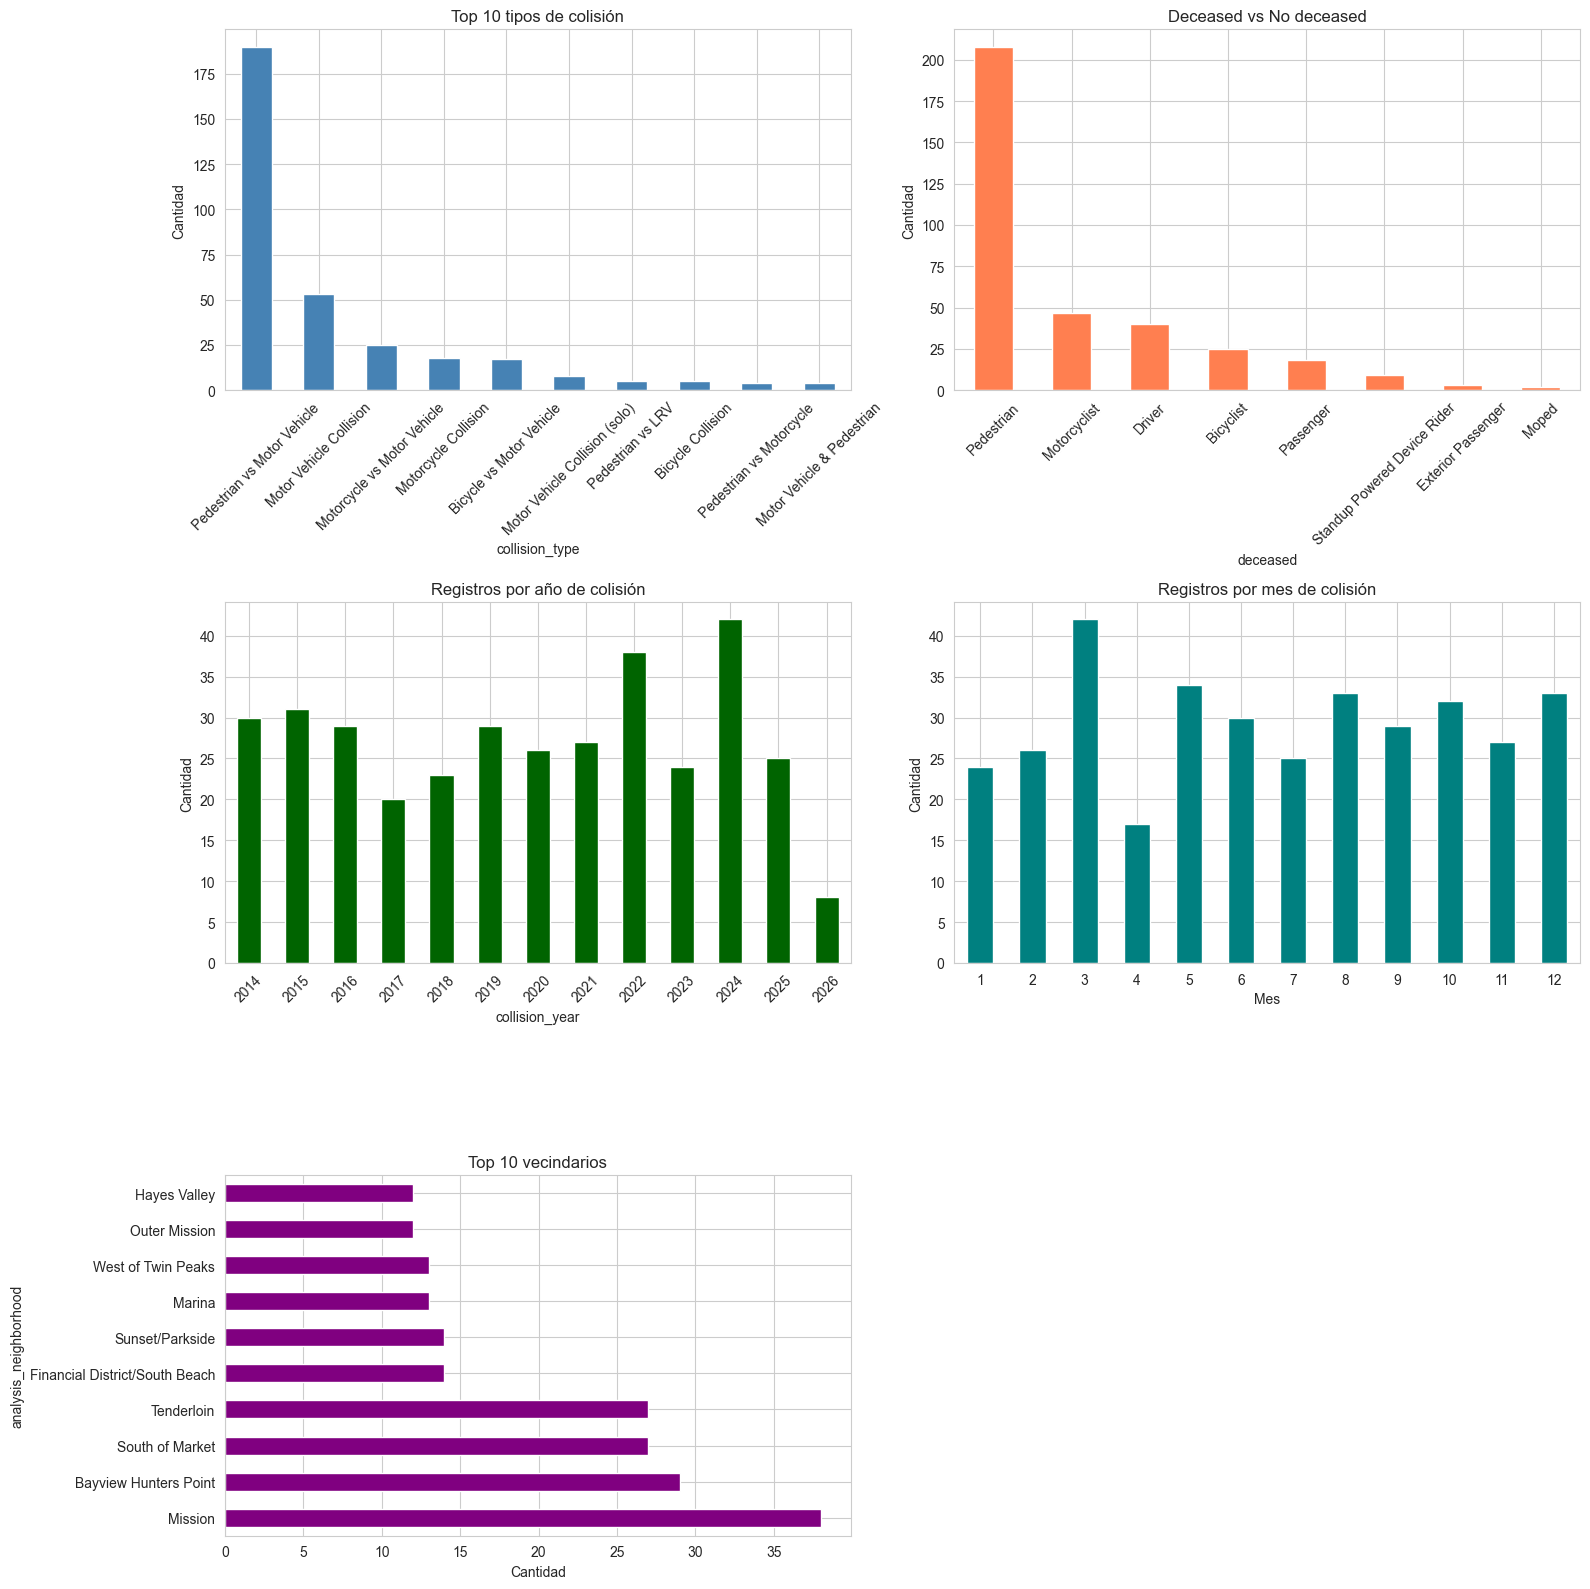

In [25]:
import matplotlib.pyplot as plt

if 'collision_datetime' in df_acc.columns:
    if 'collision_year' not in df_acc.columns:
        df_acc['collision_year'] = df_acc['collision_datetime'].dt.year.astype('Int64')
    if 'collision_month' not in df_acc.columns:
        df_acc['collision_month'] = df_acc['collision_datetime'].dt.month.astype('Int64')

fig, axes = plt.subplots(3, 2, figsize=(16, 16))
axes = axes.flatten()  
plot_idx = 0

if 'collision_type' in df_acc.columns:
    df_acc['collision_type'].value_counts().head(10).plot(kind='bar', ax=axes[plot_idx], color='steelblue')
    axes[plot_idx].set_title('Top 10 tipos de colisión')
    axes[plot_idx].set_ylabel('Cantidad')
    axes[plot_idx].tick_params(axis='x', rotation=45)
    plot_idx += 1

if 'deceased' in df_acc.columns:
    df_acc['deceased'].value_counts().plot(kind='bar', ax=axes[plot_idx], color='coral')
    axes[plot_idx].set_title('Deceased vs No deceased')
    axes[plot_idx].set_ylabel('Cantidad')
    axes[plot_idx].tick_params(axis='x', rotation=45)
    plot_idx += 1

if 'collision_year' in df_acc.columns:
    df_acc['collision_year'].value_counts().sort_index().plot(kind='bar', ax=axes[plot_idx], color='darkgreen')
    axes[plot_idx].set_title('Registros por año de colisión')
    axes[plot_idx].set_ylabel('Cantidad')
    axes[plot_idx].tick_params(axis='x', rotation=45)
    plot_idx += 1

if 'collision_month' in df_acc.columns:
    df_acc['collision_month'].value_counts().sort_index().plot(kind='bar', ax=axes[plot_idx], color='teal')
    axes[plot_idx].set_title('Registros por mes de colisión')
    axes[plot_idx].set_ylabel('Cantidad')
    axes[plot_idx].set_xlabel('Mes')
    axes[plot_idx].tick_params(axis='x', rotation=0)
    plot_idx += 1

if 'analysis_neighborhood' in df_acc.columns:
    df_acc['analysis_neighborhood'].value_counts().head(10).plot(kind='barh', ax=axes[plot_idx], color='purple')
    axes[plot_idx].set_title('Top 10 vecindarios')
    axes[plot_idx].set_xlabel('Cantidad')
    plot_idx += 1

for i in range(plot_idx, len(axes)):
    fig.delaxes(axes[i])

plt.tight_layout()
plt.show()


## 10. Análisis espacial

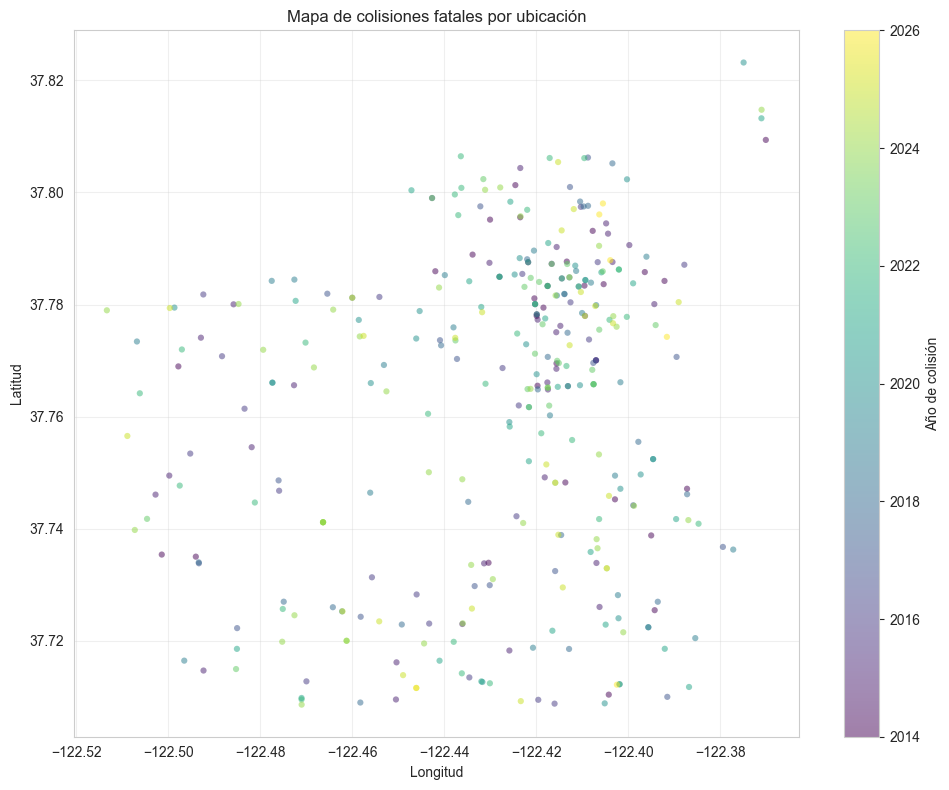

In [26]:
fig, ax = plt.subplots(figsize=(10, 8))
if 'collision_year' not in df_acc.columns and 'collision_datetime' in df_acc.columns:
    df_acc['collision_year'] = df_acc['collision_datetime'].dt.year.astype('Int64')
mask = df_acc['latitude'].notna() & df_acc['longitude'].notna()
sc = ax.scatter(
    df_acc.loc[mask, 'longitude'],
    df_acc.loc[mask, 'latitude'],
    c=df_acc.loc[mask, 'collision_year'].fillna(0),
    cmap='viridis',
    alpha=0.5,
    s=20,
    edgecolors='none'
)
ax.set_title('Mapa de colisiones fatales por ubicación')
ax.set_xlabel('Longitud')
ax.set_ylabel('Latitud')
cbar = plt.colorbar(sc, ax=ax)
cbar.set_label('Año de colisión')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


## 11. Detección de duplicados y registros únicos

In [27]:
print('Duplicados en unique_id:', df_acc['unique_id'].duplicated().sum())
print('Duplicados completos en filas:', df_acc.duplicated().sum())
print('Registros únicos de case_id_fkey:', df_acc['case_id_fkey'].nunique())

Duplicados en unique_id: 0
Duplicados completos en filas: 0
Registros únicos de case_id_fkey: 343


## 12. Primeras y últimas filas del dataset

In [28]:
print('Primeras 10 filas:')
print(df_acc.head(10).to_string(index=False))
print('Últimas 10 filas:')
print(df_acc.tail(10).to_string(index=False))

Primeras 10 filas:
 unique_id case_id_fkey  latitude   longitude      death_datetime  collision_datetime                            location  age    sex     deceased              collision_type street_type analysis_neighborhood  case_id_fkey_missing  age_imputed  age_imputed_flag  collision_year  collision_month
         1    140236301 37.710409 -122.404226 2014-03-20 11:21:00 2014-03-20 00:00:00   Bayshore Blvd near Visitation Ave 82.0 Female   Pedestrian Pedestrian vs Motor Vehicle City Street Bayview Hunters Point                 False         82.0             False            2014                3
         2    140755533 37.725476 -122.394243 2014-09-08 16:38:00 2014-09-08 05:10:00                3rd St at Carrol Ave 71.0   Male   Pedestrian           Pedestrian vs LRV City Street Bayview Hunters Point                 False         71.0             False            2014                9
         3    151078623 37.726049 -122.406232 2015-12-14 10:30:00 2015-12-14 10:15:00           